#**Airline Pricing and Route Profitability Analysis**

This project focuses on the Exploratory Data Analysis and Feature Engineering phases of the **Airline Pricing and Route Profitability Analysis** Dataset. The technical foundation for the data processing and initial visualizations is adapted from the excellent work by *Emanuel Lázaro* on [Kaggle](https://www.kaggle.com/code/emanuellcs/airline-route-profitability-cost-analysis#4.-Cost-Structure-Decomposition).

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "waleedfaheem/airline-route-profitability-and-cost-analysis",
    # Replace with the actual filename, e.g. "airline_data.csv"
    "airline_route_profitability.csv",
)

Using Colab cache for faster access to the 'airline-route-profitability-and-cost-analysis' dataset.


#Initial setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

# Global plot configuration
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold'
})

PALETTE_ROUTE = {'Short Haul': '#2196F3', 'Medium Haul': '#FF9800', 'Long Haul': '#4CAF50'}
PALETTE_SEASON = {'Peak': '#E53935', 'Shoulder': '#FB8C00', 'Normal': '#43A047', 'Low': '#1E88E5'}


print('All libraries loaded successfully.')


All libraries loaded successfully.


# Data Quality Assessment and Data Cleaning

In [ ]:
print("======= Column Data Types =======")
print(df.dtypes)
print()
print("======= Missing Values =======")
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({'Missing values': missing , 'Missing percentage': missing_pct})
print(missing_df[missing_df['Missing values'] > 0 ])

======= Column Data Types =======
Flight_Number               object
Flight_Date                 object
Origin                      object
Destination                 object
Route                       object
Aircraft_Type               object
Aircraft_Capacity            int64
Passengers                   int64
Load_Factor                float64
Flight_Hours               float64
Season                      object
Route_Category              object
Demand_Level                object
Ticket_Revenue             float64
Ancillary_Revenue          float64
Total_Revenue              float64
Fuel_Cost                  float64
Maintenance_Cost           float64
Crew_Cost                  float64
Depreciation_Cost          float64
Insurance_Cost             float64
Airport_Fees               float64
Catering_Cost              float64
Handling_Cost              float64
Navigation_Fees            float64
Sales_Distribution_Cost    float64
Passenger_Service_Cost     float64
Overhead_Cost        

In [ ]:
from IPython.display import display, HTML
print("===== Duplicate Values =====")
print(f"Exactly duplicated rows: {df.duplicated().sum()}")
print()

print("===== Numerical Summary =====")
# Used HTML to give a better view of describe results

display(HTML(df.describe(include='number').T.round(2).to_html()))
print()

===== Duplicate Values =====
Exactly duplicated rows: 0

===== Numerical Summary =====


,count,mean,std,min,25%,50%,75%,max
Aircraft_Capacity,7974.0,317.80,98.77,180.00,296.00,325.00,396.00,517.00
Passengers,7974.0,254.82,88.14,104.00,180.25,246.00,302.00,491.00
Load_Factor,7974.0,0.80,0.09,0.58,0.74,0.80,0.87,0.95
Flight_Hours,7974.0,6.33,4.56,1.20,3.20,4.50,7.50,16.50
Ticket_Revenue,7974.0,264383.87,237102.21,14812.34,56429.51,182620.36,412696.93,1303644.62
Ancillary_Revenue,7703.0,33073.72,30167.52,1616.62,7234.40,22842.85,51234.98,192921.91
Total_Revenue,7974.0,297436.20,266832.89,16650.02,63502.39,204812.59,463800.24,1496566.53
Fuel_Cost,7974.0,46296.41,43123.04,2592.62,16137.58,28344.95,74832.96,191047.78
Maintenance_Cost,7974.0,18973.22,17677.19,1380.00,7040.00,11200.00,30800.00,72500.00
Crew_Cost,7974.0,8905.12,7414.77,936.00,3840.00,5850.00,13000.00,29000.00


In [ ]:
df.head()

,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,...,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,...,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,...,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,...,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,...,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,...,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


In [ ]:
# working copy
df1 = df.copy()

#Date formatting and date value Extraction
df1['Flight_Date'] = pd.to_datetime(df1['Flight_Date'])
df1['Month'] = df1['Flight_Date'].dt.month
df1['Month_Name'] = df1['Flight_Date'].dt.strftime('%b')
df1['Quarter'] = df1['Flight_Date'].dt.quarter
df1['Day_of_Week'] = df1['Flight_Date'].dt.day_name()



#Load factor calculation consistency cheques
df1['Load_Factor_Computed'] = df1['Passengers']/df1['Aircraft_Capacity']
load_factor_difference = (df1['Load_Factor_Computed'] - df1['Load_Factor']).abs()
print(f'Max difference in computed and provided load factor is: {load_factor_difference.max():.6f}')


#Profit calculation consistency cheques
df1['Profit_Computed'] = df1['Total_Revenue'] - df1['Total_Cost']
profit_difference = (df1['Profit_Computed'] - df1['Profit']).abs()
print(f'Max difference in computed and provided profit is: {profit_difference.max():.4f}')


#Profit marging calculation consistency cheques
df1['Profit_Margin_Computed'] = (df1['Profit']/df1['Total_Revenue']*100).round(2)
profit_margin_difference = (df1['Profit_Margin_Computed'] - df1['Profit_Margin']).abs()
print(f'Max difference between computed and provided profit margin is : {profit_margin_difference.max():.4f}')
print()
print("Data Quality check passed, proceed with analysis")






Max difference in computed and provided load factor is: 0.005589
Max difference in computed and provided profit is: 0.0100
Max difference between computed and provided profit margin is : 0.0100

Data Quality check passed, proceed with analysis


# Feature Engineering

In [ ]:
cost_columns = [col for col in df1.columns if col.endswith('_Cost') or col.endswith('Fees')]
print(cost_columns)

['Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost']


In [ ]:
# Reusable columns names
DIRECT_COST = ['Fuel_Cost','Maintenance_Cost', 'Crew_Cost','Depreciation_Cost','Insurance_Cost']
SERVICE_COST = ['Catering_Cost','Handling_Cost', 'Airport_Fees','Navigation_Fees']
INDIRECT_COST = ['Sales_Distribution_Cost','Marketing_Cost','IT_Systems_Cost','Overhead_Cost','Passenger_Service_Cost']

ALL_COST_COLS = DIRECT_COST + SERVICE_COST + INDIRECT_COST


#Revenue per passenger
df1['Revenue_Per_Passenger'] = df1['Total_Revenue']/df1['Passengers']
#Cost per passenger
df1['Cost_Per_Passenger'] = df1['Total_Cost']/df1['Passengers']
#Fuel percentage total cost
df1['Fuel_Percentage'] = df1['Fuel_Cost']/df1['Total_Cost']
#Is profitable Indicator
df1['Is_Profitable'] = (df1['Profit'] > 0).astype(int)

#Estimated Distance assuming average speed 850
df1['Estimated_Distance'] = df1['Flight_Hours'] * 850



#CASK - Cost per available seat kilometer
df1['CASK'] = df1['Total_Cost']/(df1['Aircraft_Capacity']*df1['Estimated_Distance'])
#RASK - Revenue per available seat kilometer
df1['RASK'] = df1['Total_Revenue']/(df1['Aircraft_Capacity']*df1['Estimated_Distance'])

print("Feature engineering is complete")
print(f"Shape of working dataframe {df1.shape}")

Feature engineering is complete
Shape of working dataframe (7974, 47)


#Exploratory Data Analysis

### EDA 1 :  Overview of Fleet route and network

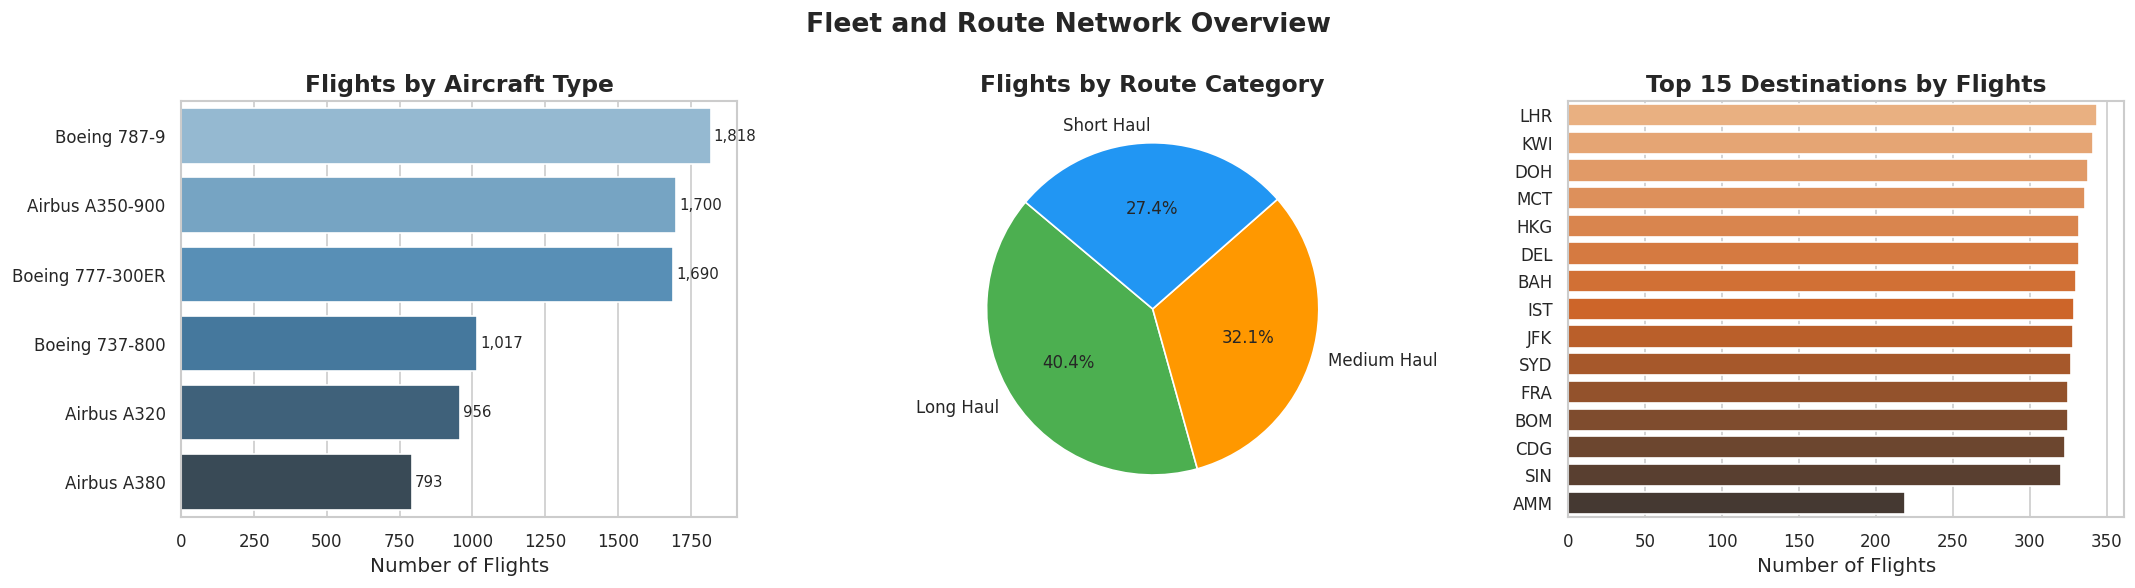

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fleet and Route Network Overview')

# Aircraft type distribution
ac_counts = df['Aircraft_Type'].value_counts()
sns.barplot(x=ac_counts.values, y=ac_counts.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Flights by Aircraft Type')
axes[0].set_xlabel('Number of Flights')
axes[0].set_ylabel('')
for bar, val in zip(axes[0].patches, ac_counts.values):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Route category distribution
rc_counts = df['Route_Category'].value_counts()
colors_rc = [PALETTE_ROUTE[c] for c in rc_counts.index]
axes[1].pie(rc_counts.values, labels=rc_counts.index, autopct='%1.1f%%',
            colors=colors_rc, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Flights by Route Category')

# Top 15 destinations by flight count
dest_counts = df['Destination'].value_counts().head(15)
sns.barplot(x=dest_counts.values, y=dest_counts.index, palette='Oranges_d', ax=axes[2])
axes[2].set_title('Top 15 Destinations by Flights')
axes[2].set_xlabel('Number of Flights')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


### EDA 2 :  Visualizing key financial metrics
Analyzing financial metrics will give us an idea about data skewness, outliers and overall picture

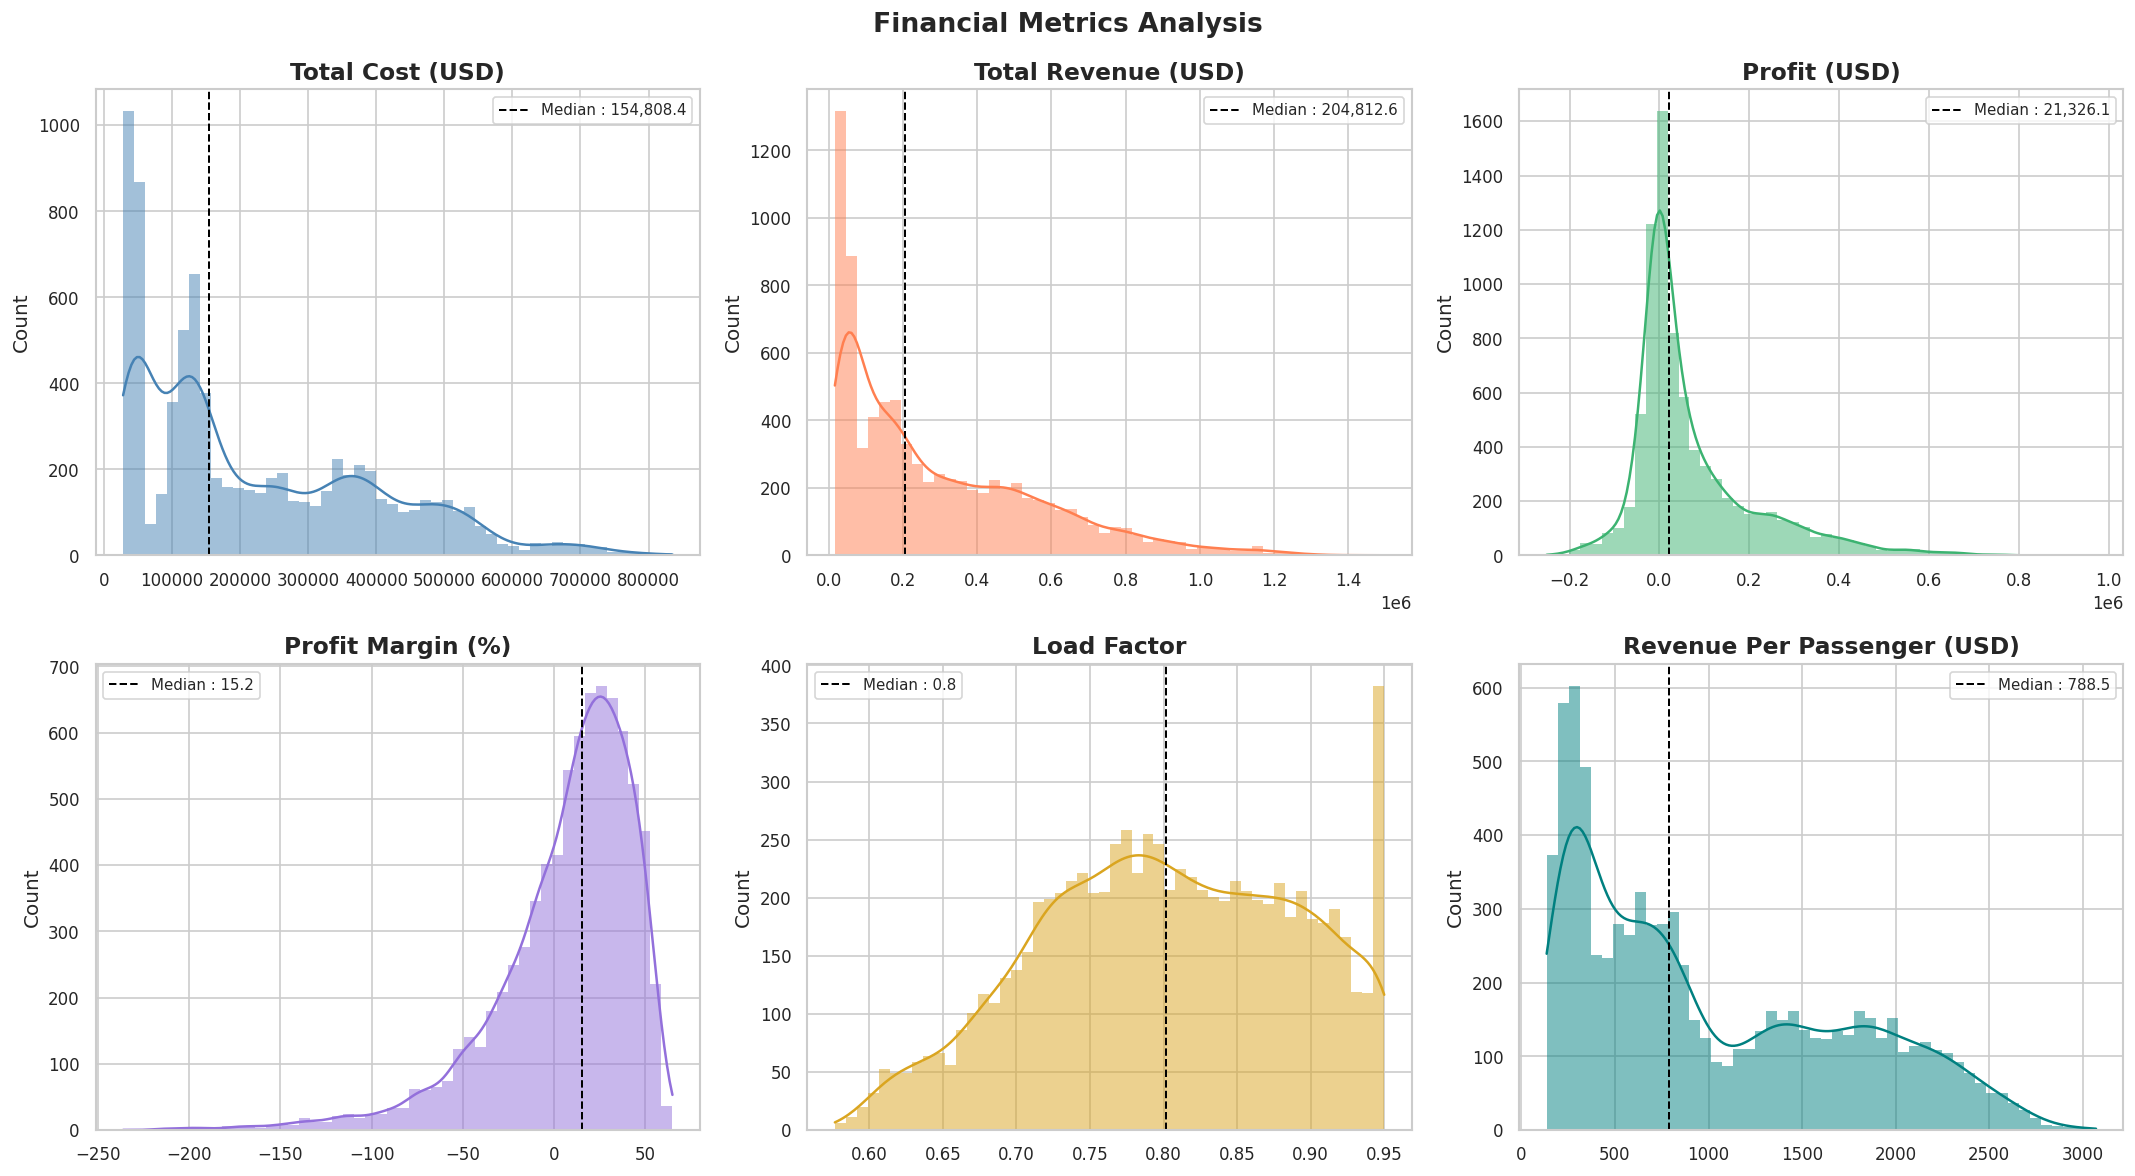

Financial metrics analysis Summary


,Total_Cost,Total_Revenue,Profit,Profit_Margin
count,7974.00,7974.00,7974.00,7974.00
mean,225266.56,297436.20,72169.63,6.19
std,174526.33,266832.89,138692.75,39.04
min,28019.38,16650.02,-250914.85,-236.27
25%,83612.37,63502.39,-9052.48,-10.75
50%,154808.35,204812.59,21326.06,15.22
75%,355441.00,463800.24,116046.09,33.28
max,835108.70,1496566.53,972133.76,64.96


In [ ]:
fig, axes = plt.subplots(2,3,figsize = (18,10))
fig.suptitle('Financial Metrics Analysis')

metrics = [
    ('Total_Cost','Total Cost (USD)', 'steelblue'  ),
    ('Total_Revenue', 'Total Revenue (USD)', 'coral'),
    ('Profit','Profit (USD)','mediumseagreen'),
    ('Profit_Margin','Profit Margin (%)','mediumpurple'),
    ('Load_Factor','Load Factor','goldenrod'),
    ('Revenue_Per_Passenger','Revenue Per Passenger (USD)','teal')
]

for ax, (col,title,color) in zip(axes.flat,metrics):
  #this is where the drawing begins
  sns.histplot(data=df1[col],bins = 50, ax = ax,color=color, kde= True, edgecolor='none',alpha=0.5)
  #this is where we plot a vertical line for median
  ax.axvline(df1[col].median(),color='black', linestyle = '--',linewidth = 1.2,label = f'Median : {df1[col].median():,.1f}')
  ax.set_title(title)
  ax.set_xlabel('')
  ax.legend(fontsize = 9)

plt.tight_layout()
plt.show()

print("Financial metrics analysis Summary")
df1[['Total_Cost','Total_Revenue','Profit','Profit_Margin']].describe().round(2)


### EDA 3 :  Route profitability visualizer

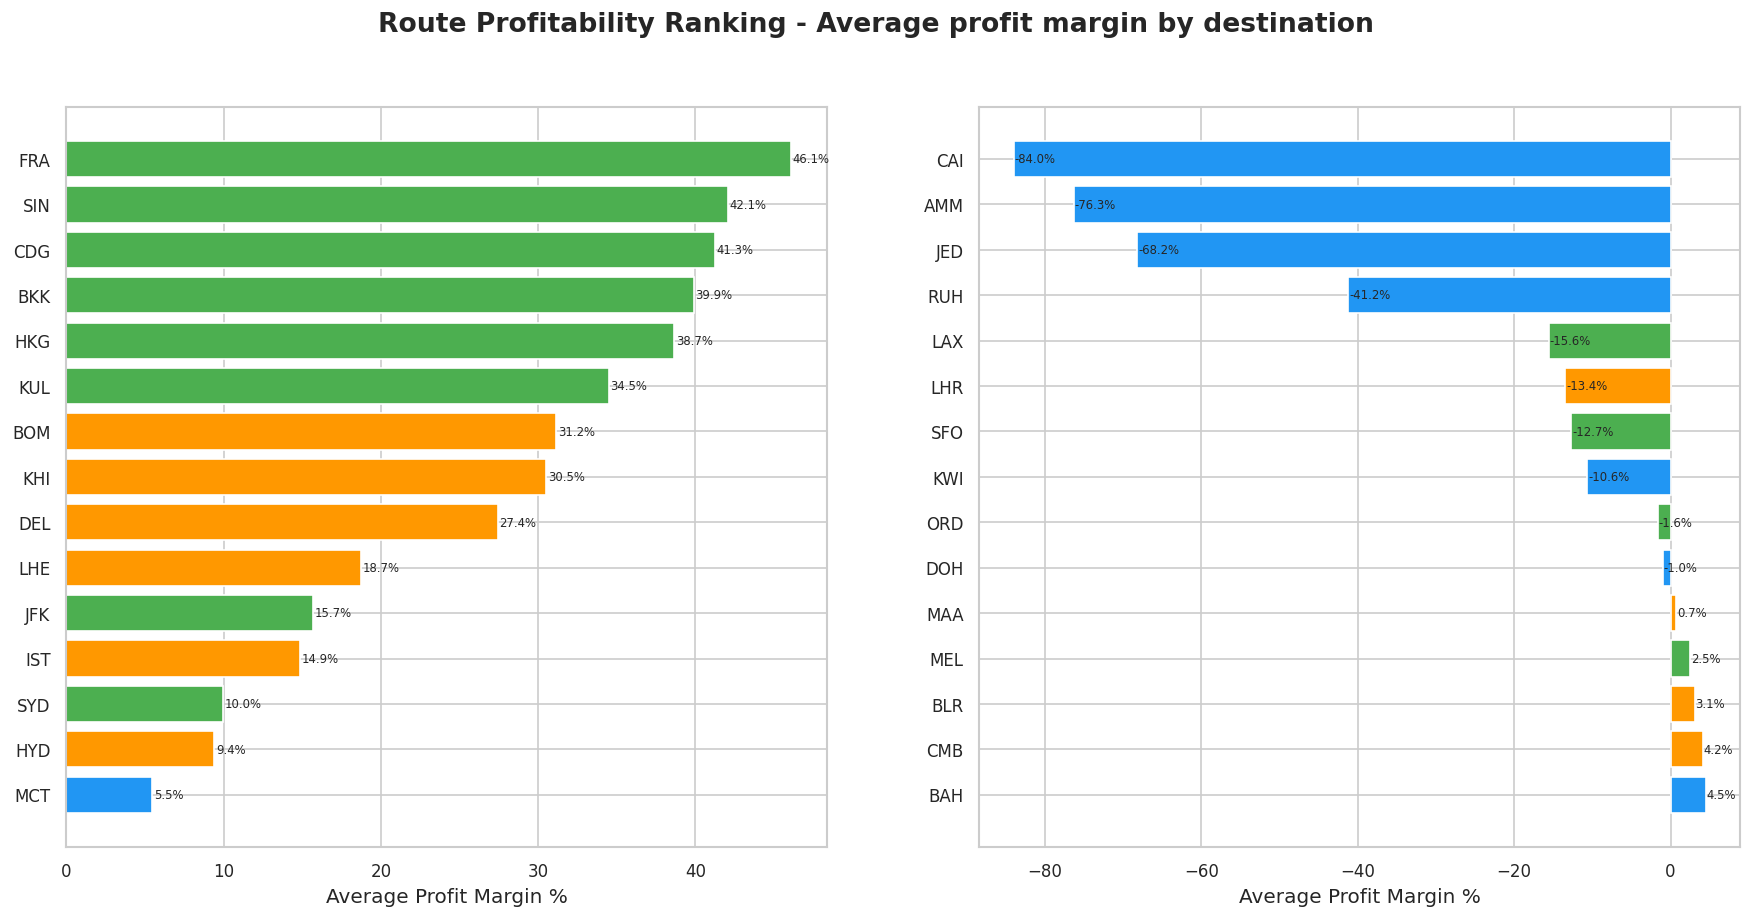

In [ ]:
route_profitability = df1.groupby(['Destination', 'Route_Category']).agg(
    Flights = ('Flight_Number','count'),
    Avg_Profit_Margin = ('Profit_Margin','mean'),
    Median_Profit_Margin = ('Profit_Margin','median'),
    Total_Profit = ('Profit','sum'),
    Total_Revenue = ('Total_Revenue','sum'),
    Avg_Load_Factor = ('Load_Factor','mean'),
    Pct_Profitable  = ('Is_Profitable','mean')
).reset_index().sort_values('Avg_Profit_Margin',ascending = False)

route_profitability['Pct_Profitable'] = (route_profitability['Pct_Profitable']*100).round(2)




fig, axes = plt.subplots(1,2,figsize =(18,8))
fig.suptitle('Route Profitability Ranking - Average profit margin by destination')

#top 15
top15 = route_profitability.head(15)
colors_top = [PALETTE_ROUTE[c] for c in top15['Route_Category']]
bars = axes[0].barh(top15['Destination'],top15['Avg_Profit_Margin'],color = colors_top)
axes[0].set_xlabel('Average Profit Margin %')
axes[0].invert_yaxis()

for bar,val in zip(bars,top15['Avg_Profit_Margin']):
  axes[0].text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2, f'{val:.1f}%' ,va= 'center', fontsize = 7)

#bottom 15
bottom15 = route_profitability.tail(15).sort_values('Avg_Profit_Margin')
colors_bottom = [PALETTE_ROUTE[c] for c in bottom15['Route_Category']]
bars = axes[1].barh(bottom15['Destination'],bottom15['Avg_Profit_Margin'],color = colors_bottom)
axes[1].invert_yaxis()
axes[1].set_xlabel('Average Profit Margin %')

for bar,val in zip(bars,bottom15['Avg_Profit_Margin']):
  axes[1].text(bar.get_width()+0.1 , bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va= 'center', fontsize = '7')



###Most Profitable flight analysis

Text(0.5, 1.0, 'Least 5 Profitable Destinations')

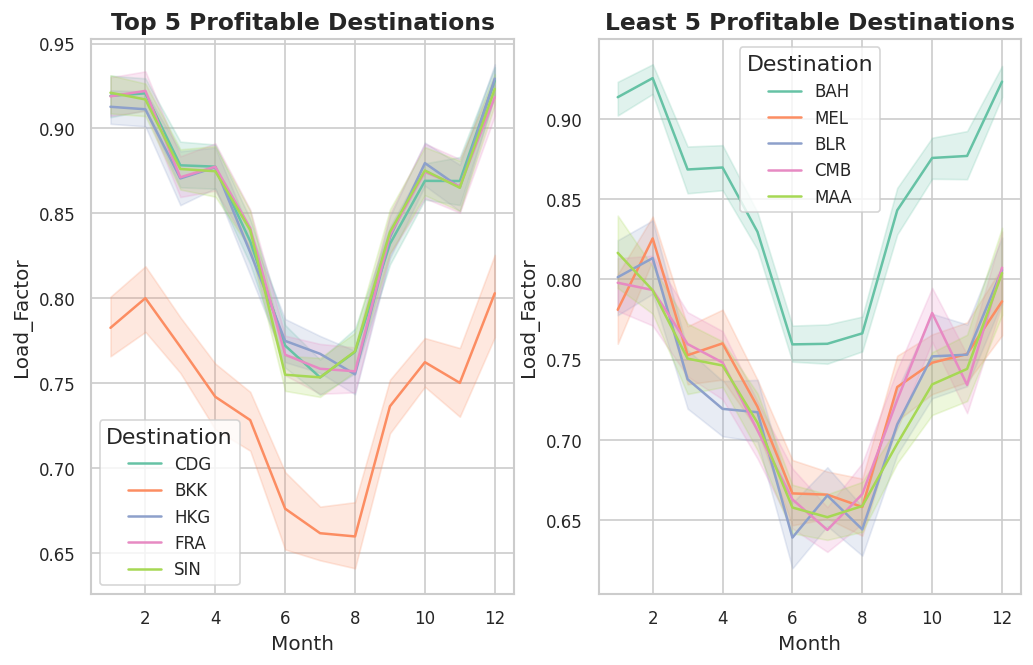

In [ ]:
top5desitnations = ['FRA','SIN','CDG','BKK','HKG']
lowe5destinations = ['BAH','CMB','BLR','MEL','MAA']
top_5_flights_data = df1[df1['Destination'].isin(top5desitnations)][['Destination','Load_Factor','Profit_Margin','Month']]
lowest_5_data = df1[df1['Destination'].isin(lowe5destinations)][['Destination','Load_Factor','Profit_Margin','Month']]

fig,axes = plt.subplots(1,2,figsize = (10,6))

sns.lineplot(
    data = top_5_flights_data,
    x = 'Month',
    y = 'Load_Factor',
    hue = 'Destination',
    palette = 'Set2',
    ax = axes[0]
)

axes[0].set_title('Top 5 Profitable Destinations')

sns.lineplot(
    data = lowest_5_data,
    x = 'Month',
    y = 'Load_Factor',
    hue = 'Destination',
    palette = 'Set2',
    ax = axes[1]
)
axes[1].set_title('Least 5 Profitable Destinations')


BKK and BAH tells us a unique story. Even though the load factor for BKK is extremely low as compared to the other top five profitable flights of the low Load Factor does not always correlate to lower profit. This means that for the destination BKK the ticket price or the cargo prices are high enough to cover all the cost and make decent amount of profit on top of it. When it comes to BAH it tells a different story. The load factor of BAH is almost the same as that of top 5 flights, which tells us this could be an operational problem. Where the costs of Landing the flight or the fuel price is high enough because of which this destination is not able to make any revenue or this can be a pricing problem where even though the plane is full, the tickets are not priced high enough for this route to be profitable. Need to analyze this further.

In [ ]:
print("Full route summary :")
route_profitability.round(2)

Full route summary :


,Destination,Route_Category,Flights,Avg_Profit_Margin,Median_Profit_Margin,Total_Profit,Total_Revenue,Avg_Load_Factor,Pct_Profitable
10,FRA,Long Haul,325,46.08,47.84,99491502.54,2.048922e+08,0.85,100.00
28,SIN,Long Haul,320,42.07,44.10,90994879.30,2.039344e+08,0.85,99.38
6,CDG,Long Haul,323,41.27,43.30,90178585.87,2.039859e+08,0.85,100.00
2,BKK,Long Haul,212,39.91,41.54,40563948.78,9.495948e+07,0.74,99.06
11,HKG,Long Haul,332,38.67,40.58,89531878.76,2.182465e+08,0.85,99.70
17,KUL,Long Haul,216,34.49,36.26,36481521.99,9.641778e+07,0.73,98.15
4,BOM,Medium Haul,325,31.16,33.50,24070355.00,6.903962e+07,0.85,98.15
16,KHI,Medium Haul,207,30.53,34.08,6302688.60,1.840677e+07,0.73,94.69
8,DEL,Medium Haul,332,27.44,29.62,21052229.00,6.803000e+07,0.85,95.18
20,LHE,Medium Haul,203,18.72,22.06,7033629.36,3.061268e+07,0.74,84.73


### 4. Profit margin by Aircraft segment

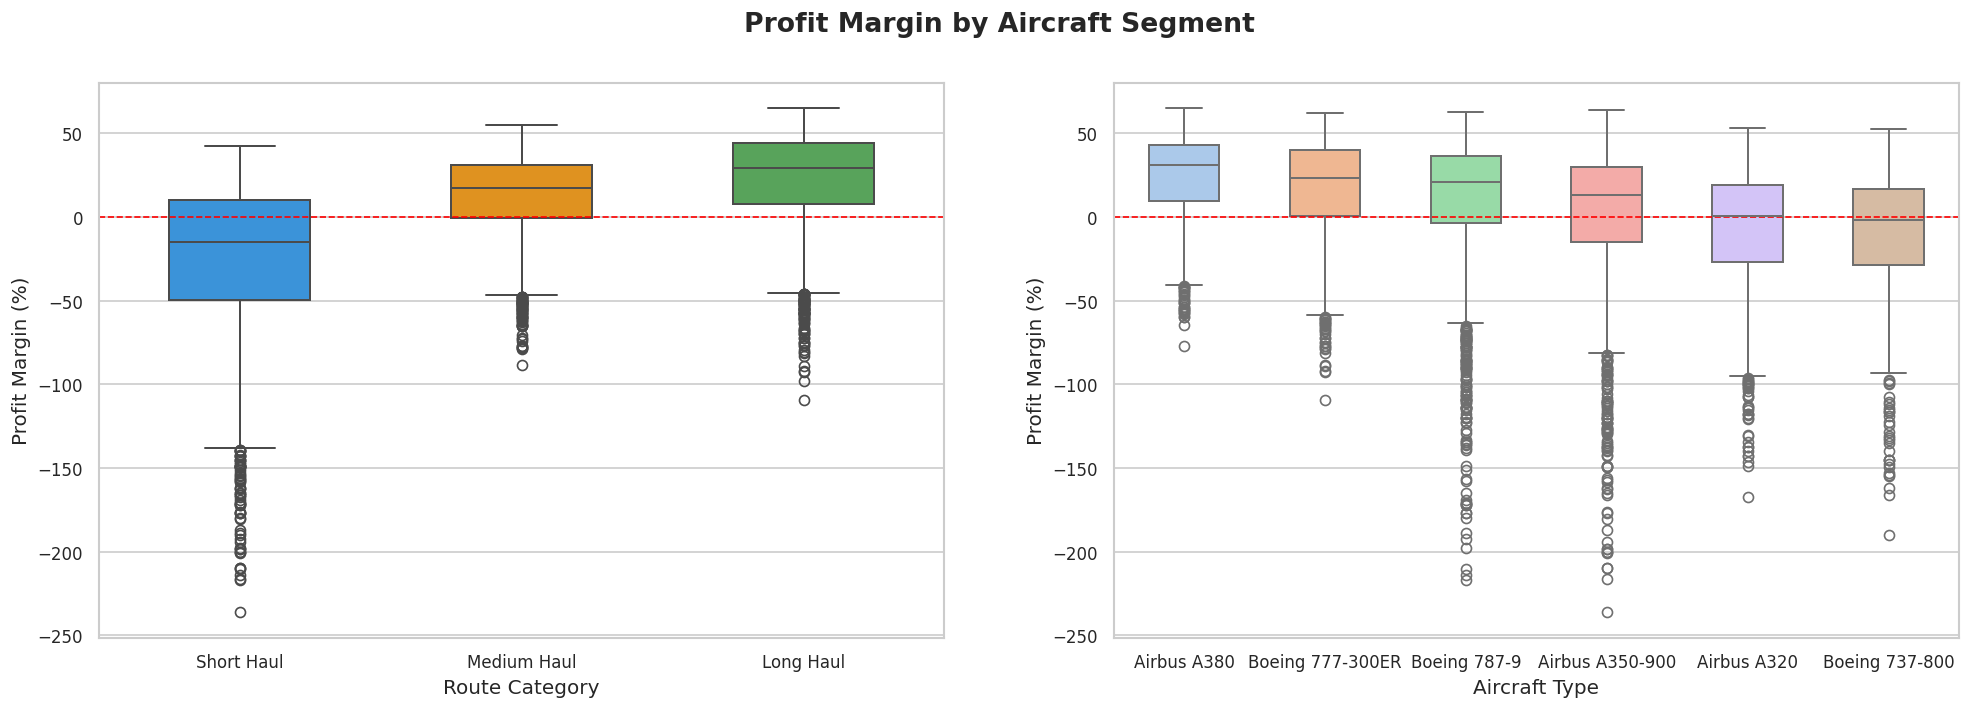

In [ ]:
fig,axes = plt.subplots(1,2,figsize = (20,6))
fig.suptitle('Profit Margin by Aircraft Segment')

cat_order = ['Short Haul','Medium Haul','Long Haul']

sns.boxplot(data = df1, x = 'Route_Category', y = 'Profit_Margin', order = cat_order,palette = PALETTE_ROUTE, ax= axes[0], width = 0.5, linewidth=1.2)
axes[0].set_ylabel('Profit Margin (%)')
axes[0].set_xlabel('Route Category')
axes[0].axhline(0,color = 'red', linestyle = '--',linewidth = 1)



actype_order = df1.groupby('Aircraft_Type')['Profit_Margin'].median().sort_values(ascending = False)

sns.boxplot(
    data= df1,
    x = 'Aircraft_Type',
    y = 'Profit_Margin',
    order = actype_order.index,
    width = 0.5,
    linewidth = 1.2,
    palette = 'pastel',
    ax = axes[1],
)
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_xlabel('Aircraft Type')
axes[1].axhline(0,color = 'red',linestyle = '--', linewidth = 1)

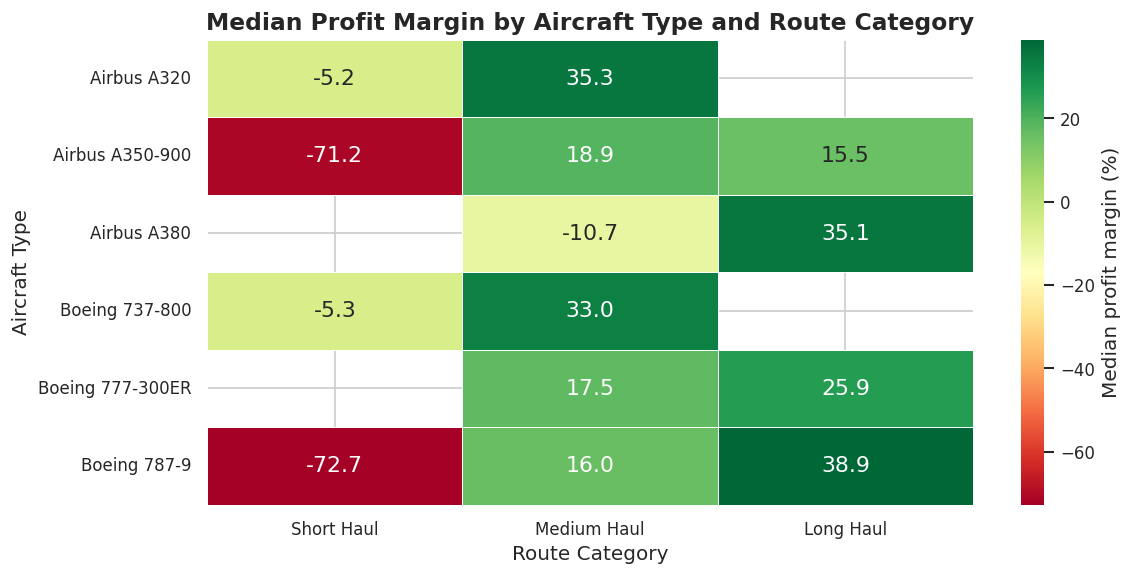

In [ ]:
#Heat map for aircraft x route category
pivot_ac_route = df1.pivot_table(
    index='Aircraft_Type',
    columns='Route_Category',
    values='Profit_Margin',
    aggfunc='median'

)[['Short Haul', 'Medium Haul', 'Long Haul']]

fig, ax = plt.subplots (figsize = (10,5))



sns.heatmap(pivot_ac_route,
            annot = True,
            cmap = 'RdYlGn',
            linewidths = 0.5,
            cbar_kws={'label' : 'Median profit margin (%)'},
            fmt = ".1f",
            ax = ax)

ax.set_title('Median Profit Margin by Aircraft Type and Route Category')
ax.set_xlabel('Route Category')
ax.set_ylabel('Aircraft Type')

plt.tight_layout()
plt.show()



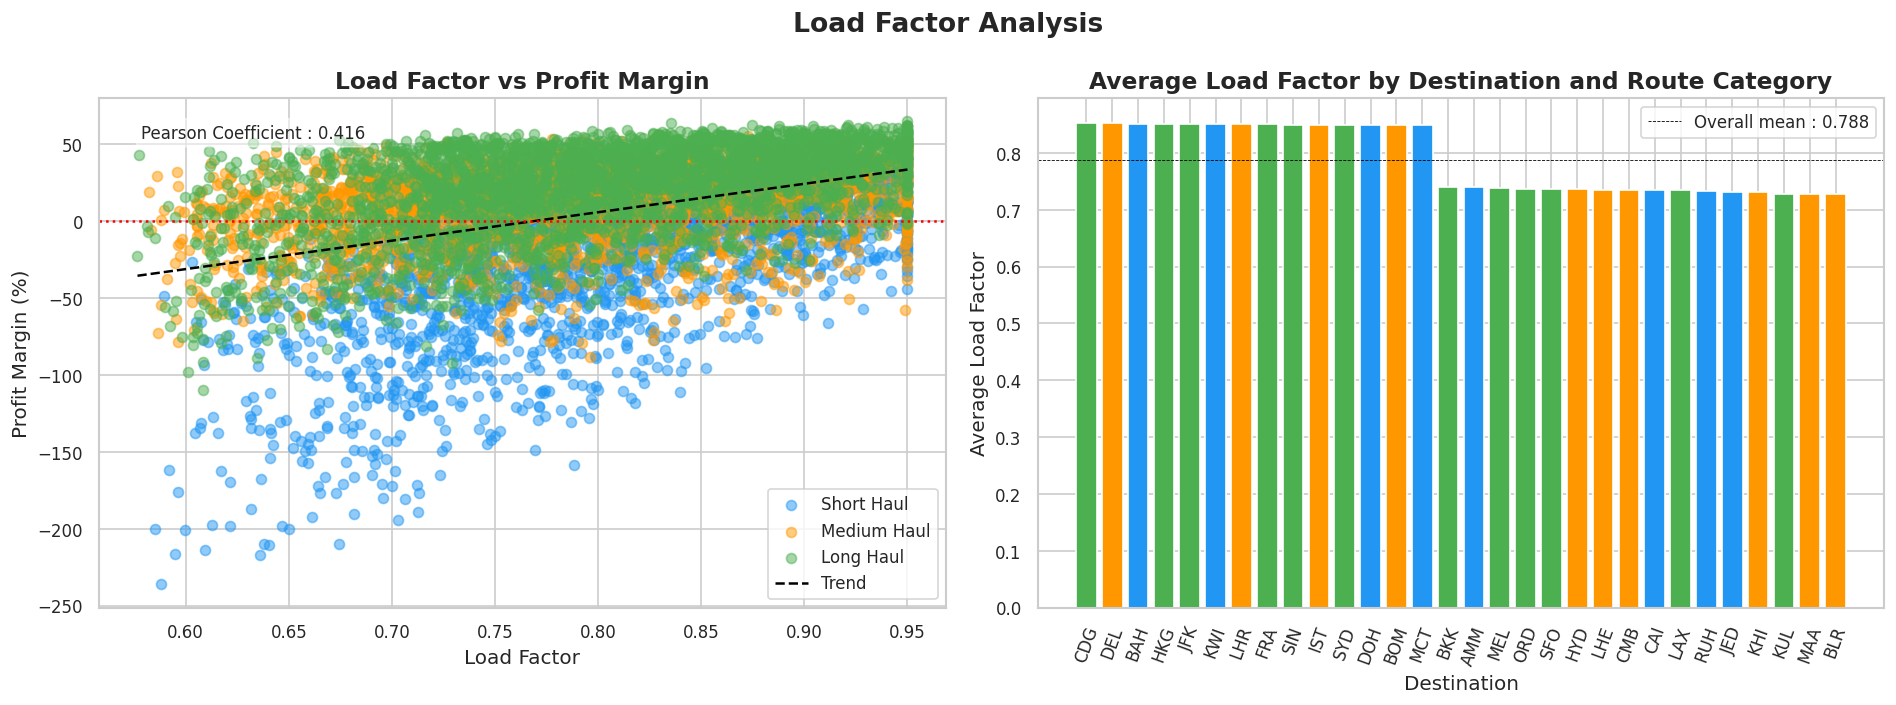

In [ ]:
fig,axes = plt.subplots(1,2, figsize = (16,6))
fig.suptitle('Load Factor Analysis')


# Load factor vs profit margin correlation analysis

for cat,color in PALETTE_ROUTE.items():
  subset = df1[df1['Route_Category'] == cat]
  axes[0].scatter(subset['Load_Factor'],subset['Profit_Margin'], color = color, alpha = 0.5, label = cat)


# Regression Line to visualize trend
from numpy.polynomial.polynomial import polyfit
x_values = df1['Load_Factor'].values
y_values = df1['Profit_Margin'].values
b,m = polyfit(x_values, y_values, 1)
x_line = np.linspace(x_values.min(), x_values.max(), 100)
axes[0].plot(x_line, m*x_line + b, linestyle = '--', color = 'black', label = 'Trend')
axes[0].axhline(0,linestyle = ':', color = 'red')
axes[0].set_xlabel('Load Factor')
axes[0].set_ylabel('Profit Margin (%)')
axes[0].legend()
axes[0].set_title('Load Factor vs Profit Margin')

#Plotting pearson coefficient
corr = df1['Load_Factor'].corr(df1['Profit_Margin'])
axes[0].text(0.05,0.95,f'Pearson Coefficient : {corr:.3f}',
             transform = axes[0].transAxes, fontsize = 10, verticalalignment = 'top',
             bbox = dict(boxstyle = 'round',alpha = 0.5,facecolor = 'white'))

#Average Load Factor by route and category
lf_category  = df1.groupby('Destination')['Load_Factor'].mean().sort_values(ascending = False)
dest_category = df1.groupby('Destination')['Route_Category'].first()
bar_color = [PALETTE_ROUTE[dest_category[d]] for d in lf_category.index]
axes[1].bar(lf_category.index,lf_category.values, color = bar_color)
axes[1].set_xlabel('Destination')
axes[1].set_ylabel('Average Load Factor')
axes[1].set_title('Average Load Factor by Destination and Route Category')
axes[1].tick_params(axis = 'x',rotation=70)
axes[1].axhline(lf_category.mean(), linestyle = '--', color = 'black', linewidth = '0.5', label = f'Overall mean : {lf_category.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Correlation Analysis

In [ ]:
numeric_columns = df1.select_dtypes(include= ['number']).columns.to_list()

#Remove reduntant columns
exclude = ['Month', 'Quarter', 'Is_Profitable', 'Load_Factor_Computed',
           'Profit_Computed', 'Profit_Margin_Computed']

numeric_columns = [col for col in numeric_columns if col not in exclude]


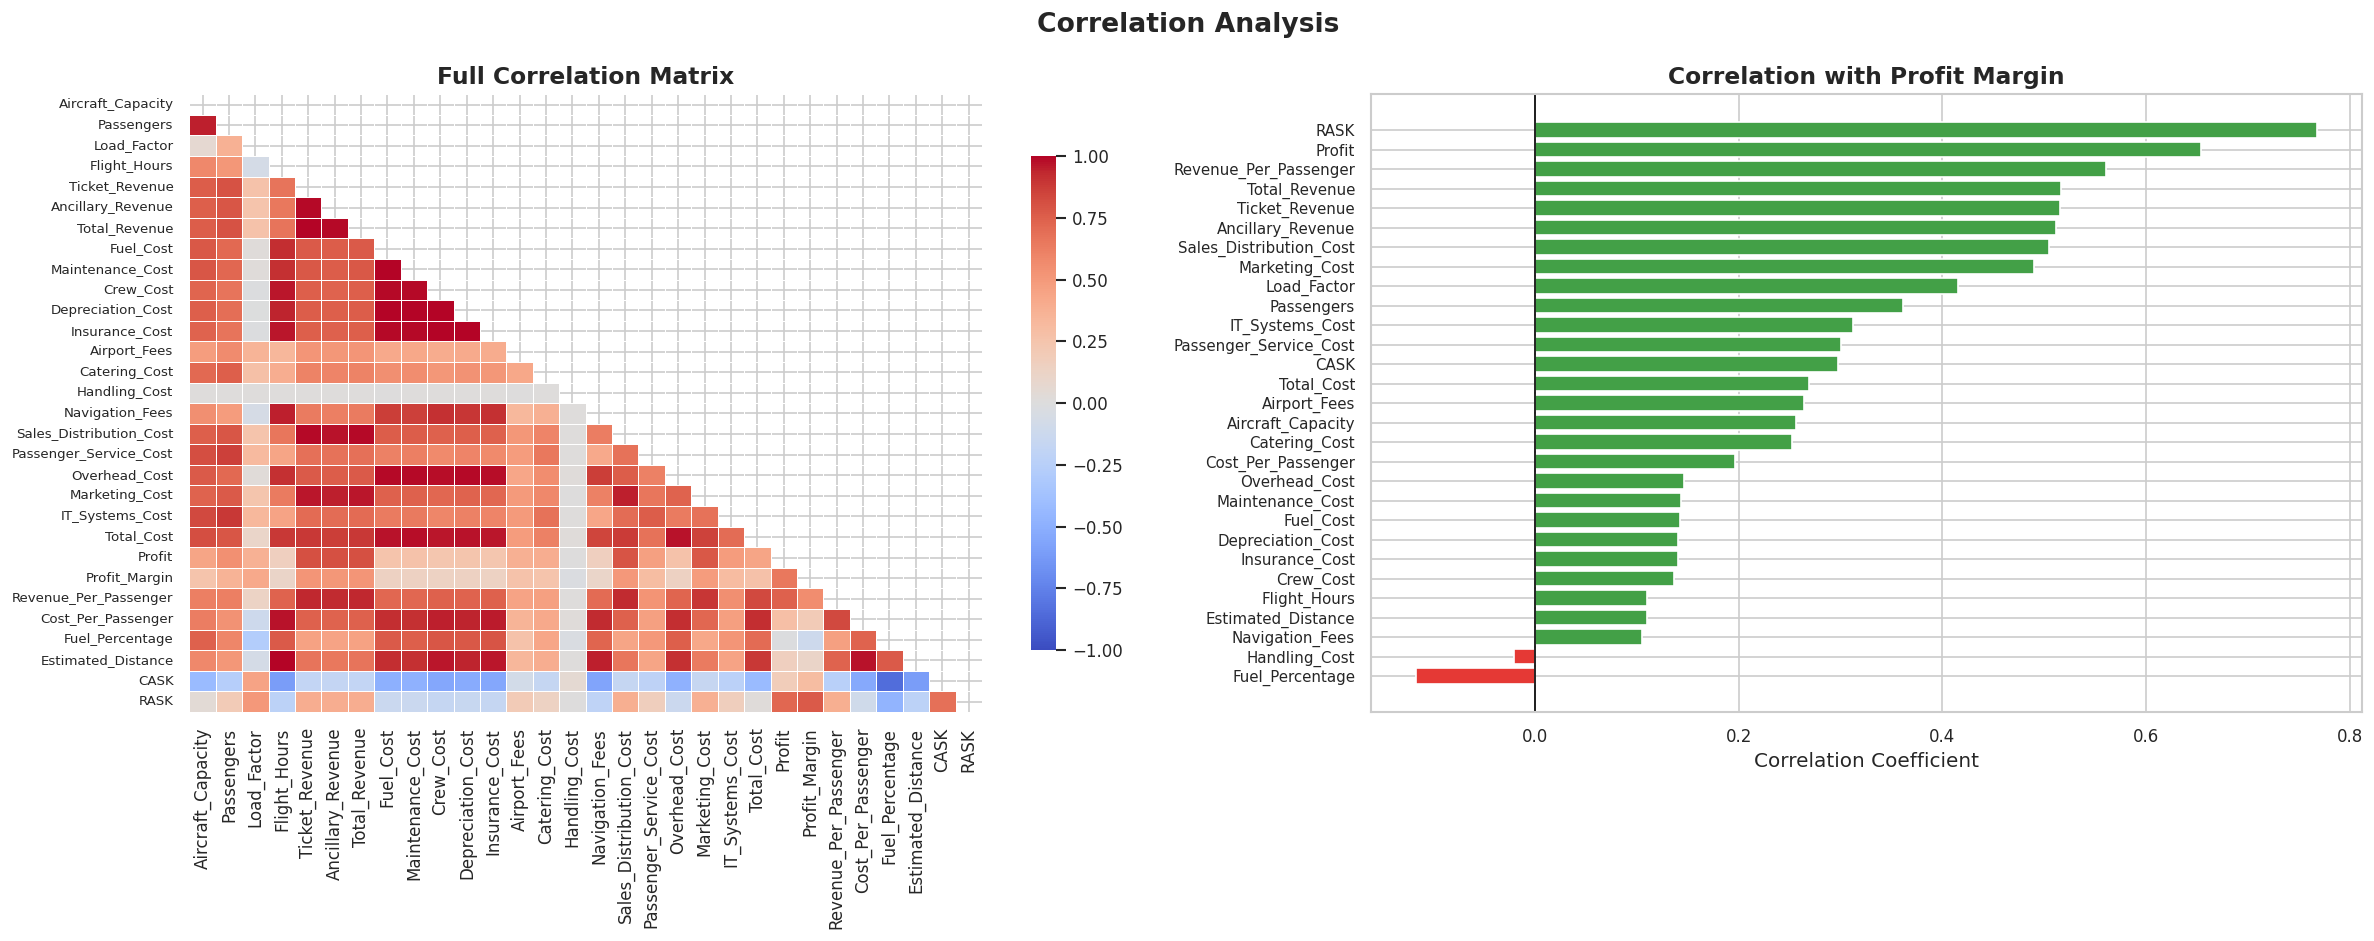

In [ ]:
correlation_matrix = df1[numeric_columns].corr()


#Targeted correlation for profit Margin
correlation_targeted = correlation_matrix['Profit_Margin'].drop('Profit_Margin').sort_values()

# Create a figure and axis
fig, ax = plt.subplots(1,2,figsize=(20,8))
fig.suptitle('Correlation Analysis')

#Full heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype = bool)) #applied triangle upper function to filter out the redundant upper triangle in heatmap
sns.heatmap(
            correlation_matrix,
            mask= mask,
            cmap = 'coolwarm',center = 0, vmin = -1, vmax = 1, #assigning mathematical values for colors, red = 1, blue = -1
            annot = False, linewidths = 0.3,
            cbar_kws = {'shrink': 0.8}, #shrinks the colorbar on the right side in heatmap
            ax = ax[0])
ax[0].set_title('Full Correlation Matrix')
ax[0].tick_params(axis = 'x', rotation = 90)
ax[0].tick_params(axis = 'y',labelsize = 8)


#correlation with target
bar_color = ['#E53935' if v < 0 else '#43A047' for v in correlation_targeted.values]
ax[1].barh(correlation_targeted.index, correlation_targeted.values, color = bar_color)
ax[1].axvline(0,color = 'black', linewidth = 1)
ax[1].set_title('Correlation with Profit Margin')
ax[1].set_xlabel('Correlation Coefficient')
ax[1].tick_params(axis = 'y',labelsize = 9)

plt.tight_layout()
plt.show()



### Cost Structure decomposition
This is extremely important analysis in airlines, goal is to split cost in 14 components with respect to route category

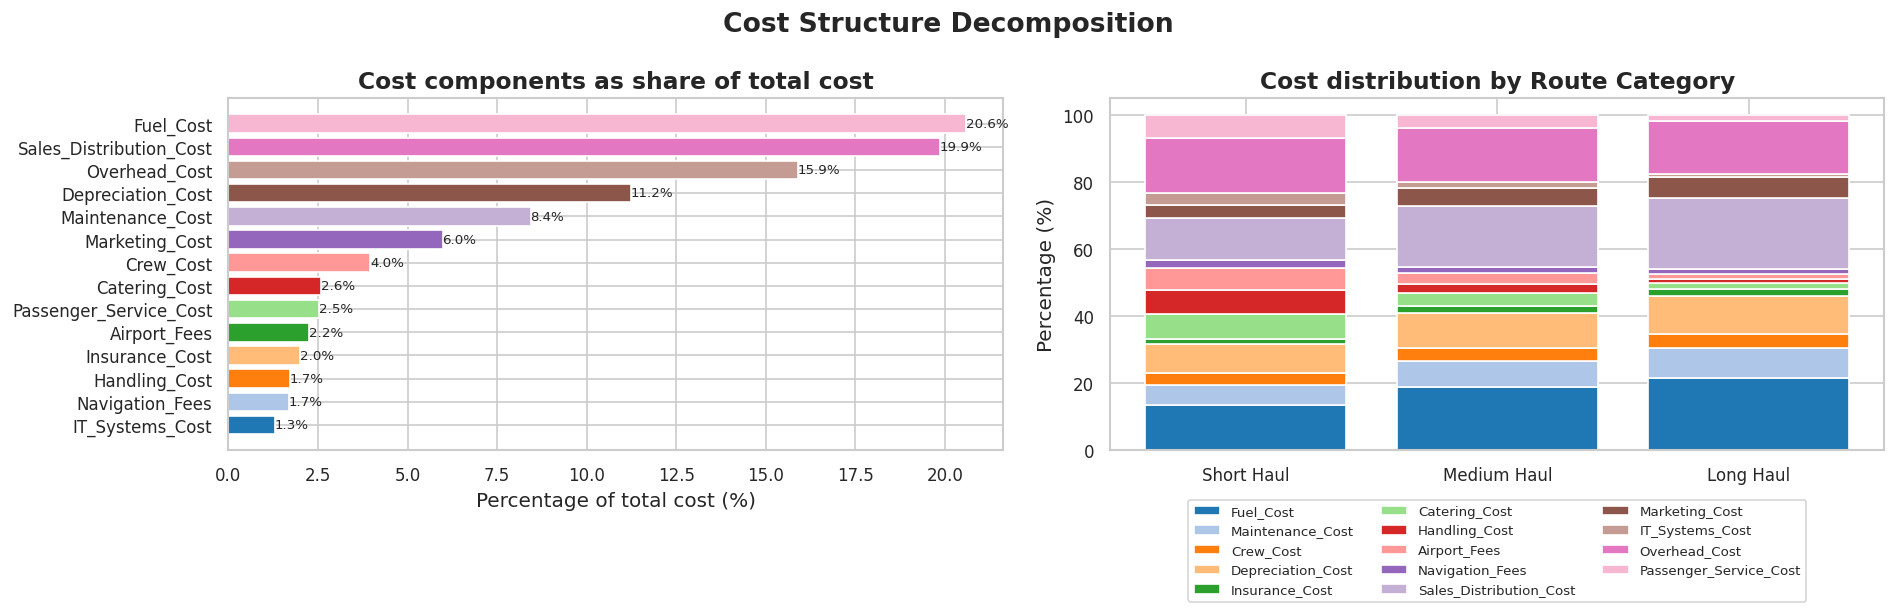

In [ ]:
# total cost distribution
total_cost = df1[ALL_COST_COLS].sum() #sum of all records on column level
pct_cost = (total_cost/total_cost.sum()*100).sort_values() #all costs summed up and percentage on column level

fig,ax = plt.subplots(1,2,figsize = (16,6))
fig.suptitle('Cost Structure Decomposition')

bar_color  = sns.color_palette('tab20', len(pct_cost))
bars = ax[0].barh(pct_cost.index,pct_cost.values, color = bar_color)
ax[0].set_title ('Cost components as share of total cost')
ax[0].set_xlabel('Percentage of total cost (%)')

#Annotation for horizantal bars
for bar,val in zip(bars, pct_cost.values):
  ax[0].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va = 'center', fontsize = 8)


#cost distribution by route category
costs_by_route = df1.groupby('Route_Category')[ALL_COST_COLS].mean()
pct_cost_route = costs_by_route.div(costs_by_route.sum(axis =1), axis =0)*100

pct_cost_route_ordered = pct_cost_route.loc[['Short Haul','Medium Haul','Long Haul']]  #sorting the data horizantally
bottom = np.zeros(3)                                                                   #setting the vertical base for values to stack up on

color_palette_treemap = sns.color_palette('tab20',len(ALL_COST_COLS))                # Unique tableau color for each cost category

for i, col in enumerate(ALL_COST_COLS):
  ax[1].bar(
      ['Short Haul','Medium Haul','Long Haul'],
      pct_cost_route_ordered[col],
      bottom = bottom,
      color = color_palette_treemap[i],
      label = col,
  )
  bottom += pct_cost_route_ordered[col].values

ax[1].set_title('Cost distribution by Route Category')
ax[1].set_ylabel('Percentage (%)')
ax[1].legend(loc = 'lower center', bbox_to_anchor = (0.5,-0.45), ncols = 3, fontsize = 8 )


plt.tight_layout()
plt.show()


### Fuel cost is the driver for costs across all the segments, deep dive analysis for Fuel costs

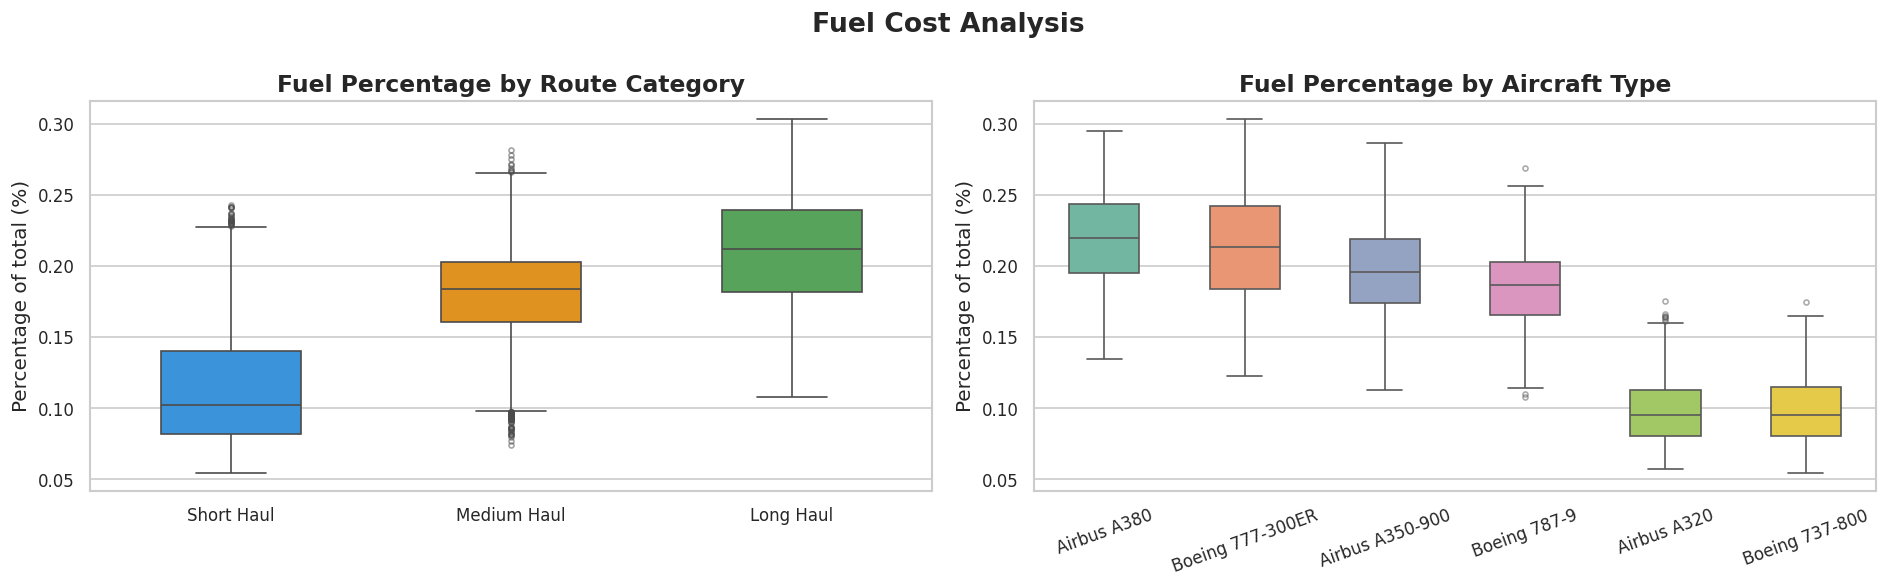

In [ ]:
fig,ax = plt.subplots(1,2, figsize = (16,5))
fig.suptitle('Fuel Cost Analysis')

#Fuel cost
sns.boxplot(
    data =df1,
    x = 'Route_Category',
    y = 'Fuel_Percentage',
    order = ['Short Haul', 'Medium Haul', 'Long Haul'],
    palette = PALETTE_ROUTE, width = 0.5,
    flierprops = dict(marker = 'o', markersize =3 , alpha = 0.5),
    ax = ax[0]

)

ax[0].set_xlabel('')
ax[0].set_ylabel('Percentage of total (%)')
ax[0].set_title('Fuel Percentage by Route Category')

# Fuel Percentage by Aircraft type

sns.boxplot(
    data = df1,
    x = 'Aircraft_Type',
    y = 'Fuel_Percentage',
    order = df1.groupby('Aircraft_Type')['Fuel_Percentage'].median().sort_values(ascending = False).index,
    ax = ax[1],
    palette = 'Set2', width = 0.5,
    flierprops = dict(marker = 'o', markersize =3 , alpha = 0.5),
)


ax[1].set_xlabel('')
ax[1].set_ylabel('Percentage of total (%)')
ax[1].set_title('Fuel Percentage by Aircraft Type')
ax[1].tick_params(axis = 'x', rotation = 20)

plt.tight_layout()
plt.show()



### CASK and RASK Analysis
These are the most important metrics for airline industry, this uncover insights about business performance and business painpoints

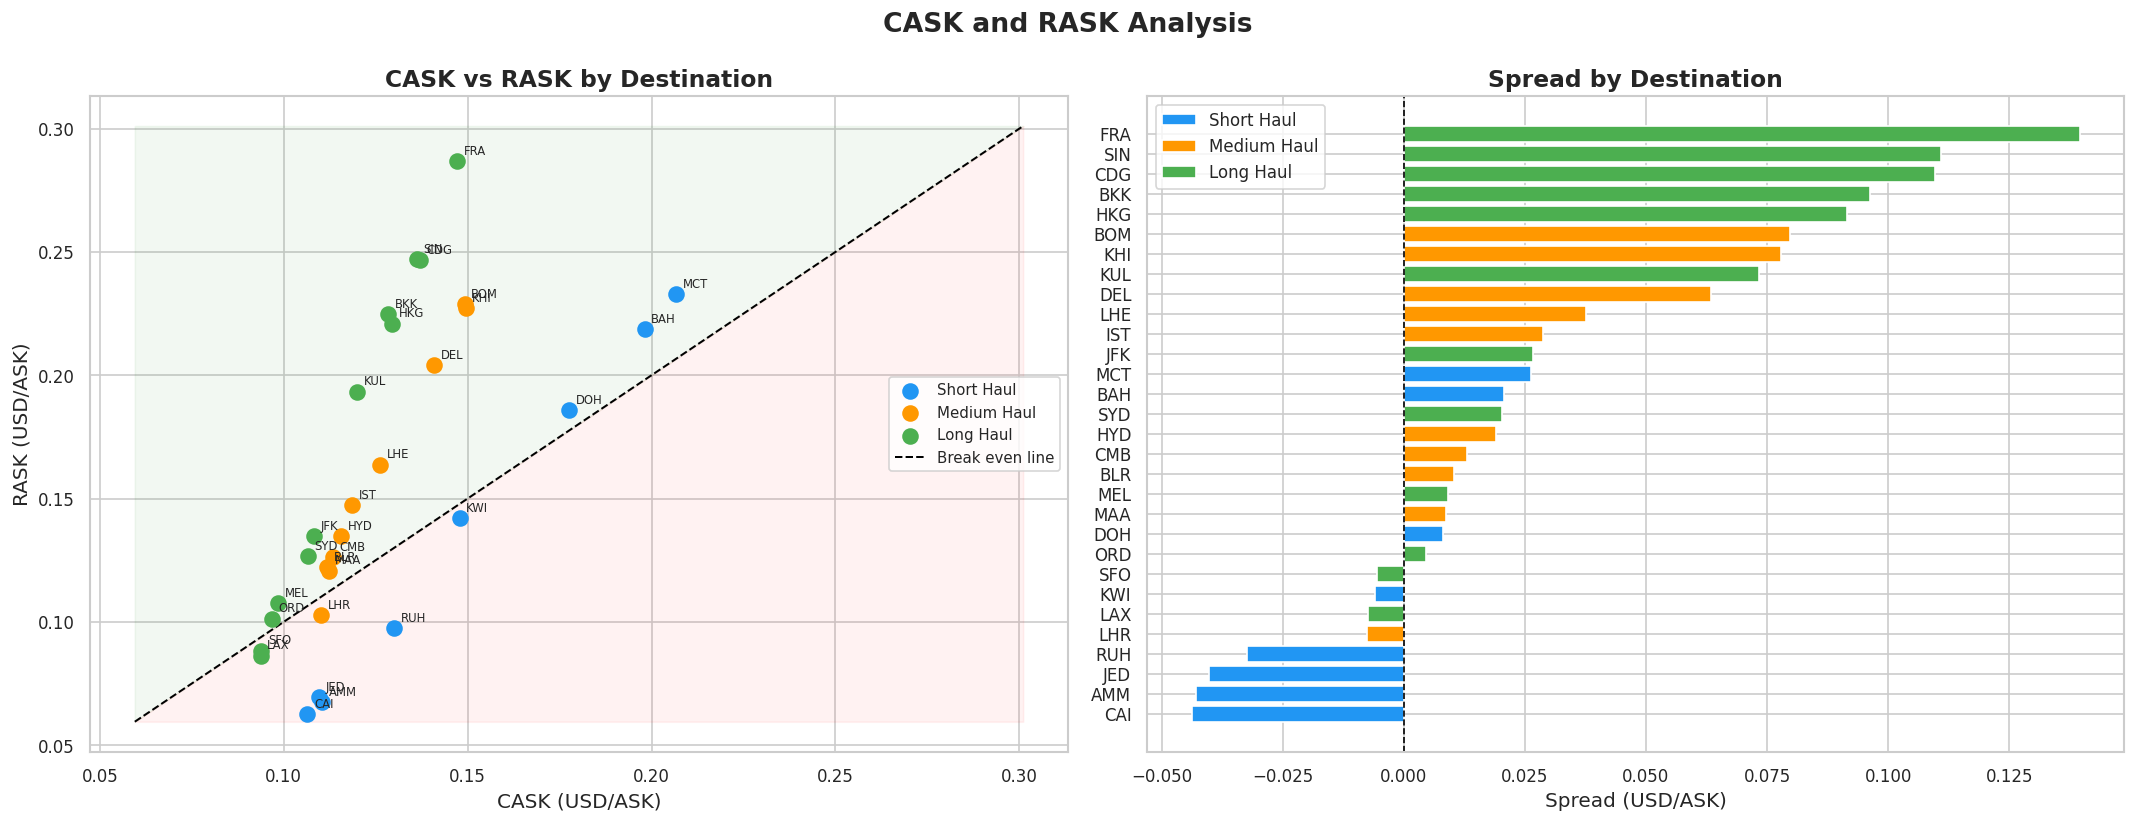

In [ ]:
cask_rask = df1.groupby('Destination').agg(
    CASK = ('CASK', 'mean'),
    RASK = ('RASK', 'mean'),
    Category = ('Route_Category', 'first')
).reset_index()

cask_rask['Spread'] = cask_rask['RASK'] - cask_rask['CASK']
cask_rask = cask_rask.sort_values('Spread', ascending = False)


fig,ax = plt.subplots(1,2, figsize = (18,7))
fig.suptitle('CASK and RASK Analysis')

#Scatter plot CASK vs RASK by destination
for cat,color in PALETTE_ROUTE.items():
  subset = cask_rask[cask_rask['Category'] == cat]
  ax[0].scatter(subset['CASK'],subset['RASK'],s=80,color = color, label = cat,zorder = 3)
  #annotation for each point on scatter plot
  for _,row in subset.iterrows():
    ax[0].annotate(
        row['Destination'],
        (row['CASK'],row['RASK']),
        textcoords = 'offset points',
        xytext = (4,4),
        fontsize = 7
    )


# 45 degree even split line
min_value = min(cask_rask['CASK'].min(),cask_rask['RASK'].min())*0.95
max_value = max(cask_rask['CASK'].max(),cask_rask['RASK'].max())*1.05

ax[0].plot([min_value,max_value],[min_value,max_value], 'k--', color = 'black', linewidth = 1.2 , label = 'Break even line')
ax[0].fill_between([min_value,max_value],[min_value,max_value],max_value,color = 'green',alpha = 0.05)
ax[0].fill_between([min_value,max_value],min_value,[min_value,max_value],color = 'red',alpha = 0.05)
ax[0].set_xlabel('CASK (USD/ASK)')
ax[0].set_ylabel('RASK (USD/ASK)')
ax[0].set_title('CASK vs RASK by Destination')
ax[0].legend(fontsize = 9)




#Spread by Destination

color_spread = [PALETTE_ROUTE[c] for c in cask_rask['Category']]
ax[1].barh(cask_rask['Destination'],cask_rask['Spread'],color = color_spread,label = 'Category')
ax[1].axvline(0,color = 'black',linestyle = '--',linewidth = 1)
ax[1].set_xlabel('Spread (USD/ASK)')
ax[1].set_title('Spread by Destination')
ax[1].invert_yaxis()

from matplotlib.patches import Patch
#Custom legen function
legend_spread = [Patch(facecolor = v,label =k) for k,v in PALETTE_ROUTE.items()]
ax[1].legend(handles = legend_spread)


plt.tight_layout()
plt.show()






###Seasonality and Demand Analysis

Airline is a seasonality based industry, we will determine how profit margin, load factor, revenue evolve across year and vary by route category and seasonal labels

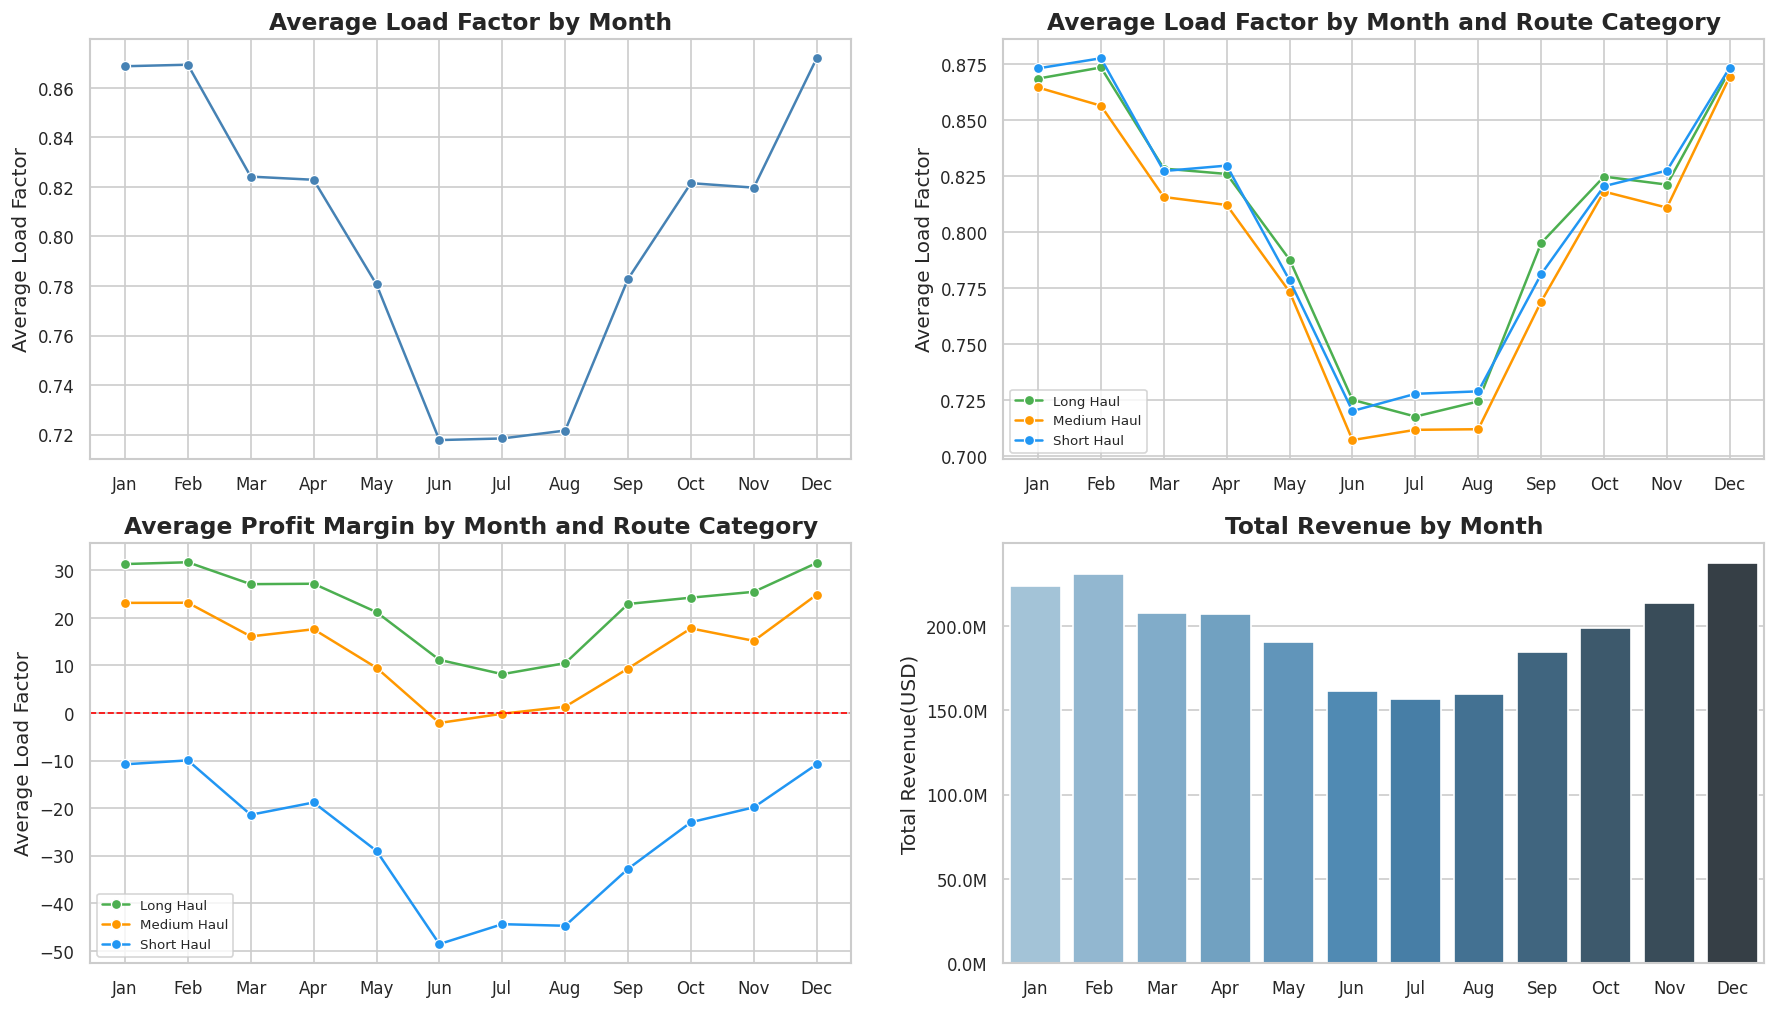

In [ ]:
#Aggregations by month and route category
month_sequence = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

metrics_by_route = df1.groupby(['Month','Month_Name','Route_Category']).agg(
    Avg_Load_Factor = ('Load_Factor','mean'),
    Avg_Profit_Margin = ('Profit_Margin','mean'),
    Total_Revenue = ('Load_Factor','sum')
).reset_index()
metrics_by_route = metrics_by_route.sort_values('Month')


metrics_by_month = df1.groupby(['Month','Month_Name']).agg(
    Avg_Load_Factor = ('Load_Factor','mean'),
    Avg_Profit_Margin = ('Profit_Margin','mean'),
    Total_Revenue = ('Load_Factor','sum')
).reset_index()
metrics_by_month = metrics_by_month.sort_values('Month')

fig,axes = plt.subplots(2,2,figsize = (18,10))

#Overall average load factor by month
sns.lineplot(
    data = metrics_by_month,
    x = 'Month_Name',
    y = 'Avg_Load_Factor',
    color = 'steelblue',
    ax = axes[0,0],
    marker = 'o',
    linewidth = 1.5
    )
axes[0,0].set_title('Average Load Factor by Month')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Average Load Factor')


#Overall average load factor in each month by category
sns.lineplot(
    data = metrics_by_route,
    x = 'Month_Name',
    y = 'Avg_Load_Factor',
    hue = 'Route_Category',
    palette = PALETTE_ROUTE,
    ax = axes[0,1],
    marker = 'o',
    linewidth = 1.5
    )
axes[0,1].set_title('Average Load Factor by Month and Route Category')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Average Load Factor')
axes[0,1].legend(fontsize=8)

#Average Profit margin by category
sns.lineplot(
    data = metrics_by_route,
    x = 'Month_Name',
    y = 'Avg_Profit_Margin',
    hue = 'Route_Category',
    palette = PALETTE_ROUTE,
    ax = axes[1,0],
    marker = 'o',
    linewidth = 1.5
    )
axes[1,0].set_title('Average Profit Margin by Month and Route Category')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Average Load Factor')
axes[1,0].axhline(0,linestyle = '--', linewidth = 1.0,color = 'red')
axes[1,0].legend(fontsize=8)


#Total Revenue by Month
rev_monthly = df1.groupby('Month')['Total_Revenue'].sum().reset_index().sort_values('Month')
sns.barplot(
    data = rev_monthly,
    x = 'Month',
    y = 'Total_Revenue',
    palette = 'Blues_d',
    ax = axes[1,1],
    #marker = 'o',
    #linewidth = 1.5
    )
axes[1,1].set_title('Total Revenue by Month')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Total Revenue(USD)')
axes[1,1].set_xticklabels(month_sequence)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

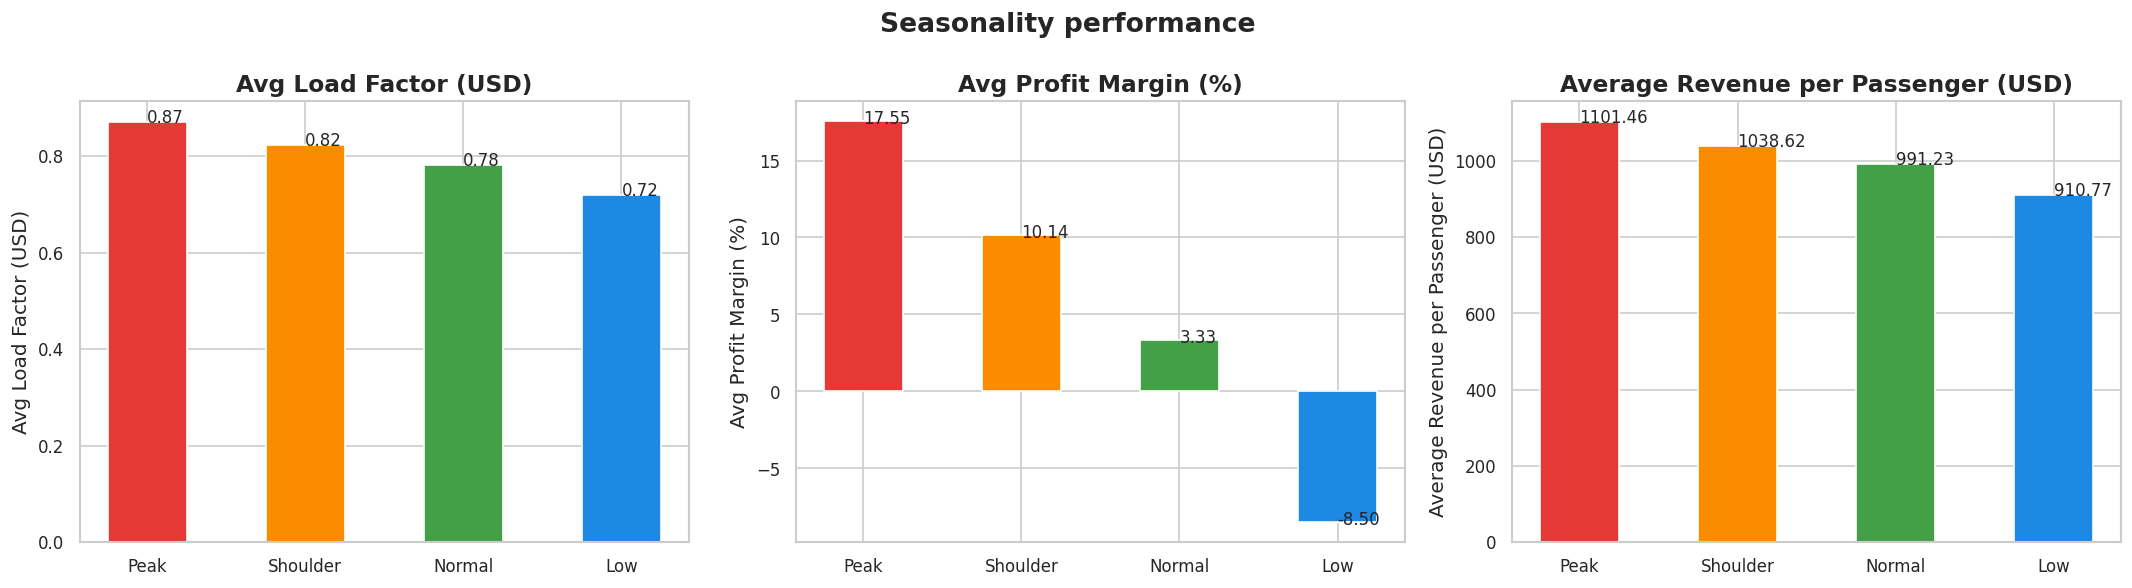

Statistics Summary for Seasonality:


Load_Factor                   Profit_Margin                     \
                mean  median       std          mean  median        std   
Season                                                                    
Low         0.719308  0.7276  0.062348     -8.500365   1.170  44.120512   
Normal      0.781693  0.7901  0.067943      3.330891  12.550  40.230789   
Peak        0.869934  0.8885  0.069053     17.546783  24.525  31.591044   
Shoulder    0.822007  0.8328  0.071298     10.139067  18.345  35.731143   

         Revenue_Per_Passenger                          
                          mean      median         std  
Season                                                  
Low                 910.769309  709.780685  633.665388  
Normal              991.226833  759.212367  704.046068  
Peak               1101.462008  864.561378  766.035525  
Shoulder           1038.617462  800.845631  729.111683

In [ ]:
#Metrics by seasonality

fig,axes = plt.subplots(1,3, figsize = (18,5))
fig.suptitle('Seasonality performance')

seasonality_order = ['Peak','Shoulder','Normal','Low']

for ax, (metric,label) in zip(axes, [
    ('Load_Factor','Avg Load Factor (USD)'),
    ('Profit_Margin','Avg Profit Margin (%)'),
    ('Revenue_Per_Passenger','Average Revenue per Passenger (USD)')
]):
  seasonality_metrics = df1.groupby('Season')[metric].mean().reindex(seasonality_order)
  colors = [PALETTE_SEASON[s] for s in seasonality_order]
  bars = ax.bar(seasonality_order, seasonality_metrics.values, color = colors , width = 0.5)
  ax.set_title(label)
  ax.set_ylabel(label)

  for bar,val in zip(bars,seasonality_metrics.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + seasonality_metrics.max()*0.01 ,f'{val:.2f}',va = 'center', fontsize = 10)

plt.tight_layout()
plt.show()


print('Statistics Summary for Seasonality:')
df1.groupby('Season')[['Load_Factor','Profit_Margin','Revenue_Per_Passenger']].agg(['mean','median','std'])




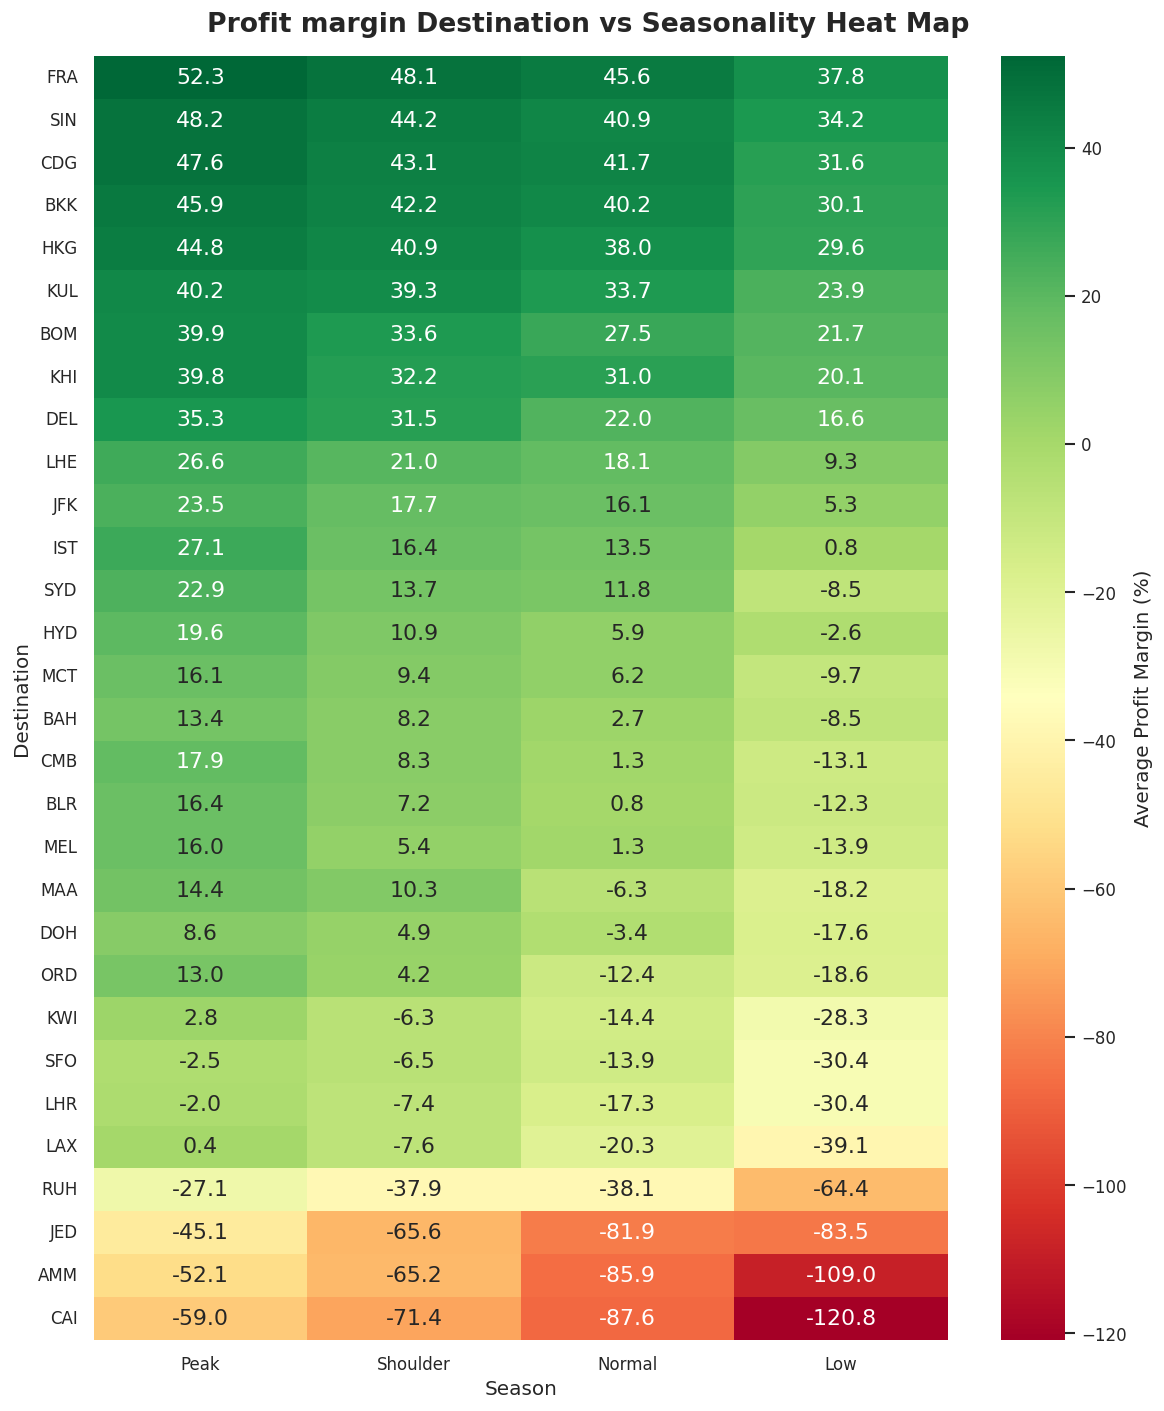

In [ ]:
#Heatmap profit margin by seasonality x Destinations

seasonality_pivot = df1.pivot_table(
    index = 'Destination',
    columns = 'Season',
    values = 'Profit_Margin',
    aggfunc = 'mean'
)[['Peak','Shoulder','Normal','Low']]   #Adjusted the order of columns

#Order rows by profit margin in descending order

destination_order_margin = df1.groupby('Destination')['Profit_Margin'].mean().sort_values(ascending = False).index

seasonality_pivot = seasonality_pivot.loc[destination_order_margin]

fig,ax = plt.subplots(figsize = (10,12))
fig.suptitle('Profit margin Destination vs Seasonality Heat Map')

sns.heatmap(seasonality_pivot,
            cmap = 'RdYlGn',
            annot = True,
            fmt = '.1f',
            cbar_kws = {'label':'Average Profit Margin (%)'},
    ax = ax)

plt.tight_layout()
plt.show()


#Key Findings

🛫 Fleet & Route Network


The fleet is distributed across multiple aircraft types serving short, medium, and long-haul routes in roughly equal proportions.
Top destinations by flight frequency reveal concentration around major international hubs (FRA, SIN, CDG, BKK, HKG).


💰 Financial Performance


Revenue, cost, and profit distributions are approximately symmetric with some outlier flights, indicating consistency in operations across most routes.
Data integrity checks passed — computed load factors, profit, and profit margins matched provided values with negligible rounding differences, confirming a clean and reliable dataset.


📍 Route Profitability


Top 5 most profitable destinations: FRA, SIN, CDG, BKK, HKG
Bottom 5 least profitable destinations: BAH, CMB, BLR, MEL, MAA
An important distinction was uncovered: BKK achieves high profitability despite a low load factor, suggesting premium pricing or cargo revenue compensates for lower passenger fill rates.
BAH presents the opposite problem: high load factors that still fail to generate profit, pointing to either elevated operational costs (fuel, landing fees) or systematic underpricing on this route.


✈️ Aircraft & Segment Analysis


Long-haul routes consistently generate the highest and most stable profit margins, with less variance compared to short and medium-haul.
Aircraft type significantly interacts with route category: certain aircraft are clearly better matched to specific haul types in terms of profitability, as shown in the median profit margin heatmap.


📦 Cost Structure


Fuel cost is the single largest cost driver across all route categories, making up the highest share of total operating cost.
Fuel percentage as a share of total cost is highest on long-haul routes and varies meaningfully by aircraft type, underscoring the importance of fuel-efficient fleet deployment.
Cost decomposition across 14 components (direct, service, and indirect costs) reveals that direct costs dominate, while indirect costs like marketing and IT remain relatively stable.


📈 Load Factor & Profitability Correlation


A positive Pearson correlation exists between load factor and profit margin, confirming that higher seat utilization generally improves profitability — but this relationship is not perfectly linear.
Outliers like BKK demonstrate that pricing strategy can override the impact of load factor.


📐 CASK vs. RASK Analysis


Most destinations sit above the breakeven line (RASK > CASK), indicating an overall profitable network.
Destinations with the widest positive RASK–CASK spread are predominantly long-haul routes, reinforcing their superior unit economics.
A few short-haul and medium-haul routes fall below the breakeven line, flagging them as candidates for route review, pricing adjustments, or cost reduction initiatives.


📅 Seasonality & Demand Patterns


Demand and profitability follow clear seasonal cycles — Peak season drives the highest load factors and revenue per passenger, while Low season sees material compression in margins.
Monthly revenue trends show pronounced peaks mid-year and around holiday periods.
The destination × season profit margin heatmap reveals that even top-performing destinations can turn unprofitable in low season, highlighting the importance of dynamic pricing and capacity management.






#Feature Engineering Summary

The following derived metrics were engineered to support deeper analysis:



* Revenue_Per_Passenger -> Total revenue normalized per passenger

* Cost_Per_Passenger -> Total cost normalized per passenger


* Fuel_Percentage -> Fuel cost as a share of total cost


* Is_Profitable -> Binary indicator (1 = profitable flight)

* Estimated_Distance -> Proxy distance using flight hours × 850 km/h

* CASK -> Cost per Available Seat Kilometer
* RASK -> Revenue per Available Seat Kilometer




#Next Steps



*   Predictive Modeling: Build regression or classification models to predict flight profitability using the engineered features.
*   Route Optimization: Use CASK/RASK spread analysis to recommend route discontinuation, frequency adjustment, or repricing.
*   Pricing Strategy: Investigate dynamic pricing opportunities for seasonal demand peaks, especially on underperforming high-load routes like BAH.
*   Fleet Efficiency Study: Model the interaction between aircraft type, route category, and fuel efficiency to guide fleet deployment decisions.
